# 02 - Prétraitement et filtrage

## Objectif
''' Préparer les images du dataset avant les étapes de segmentation et de décision.'''

## Travail réalisé
''' - chargement des images
- redimensionnement
- normalisation
- filtrage gaussien
- filtrage médian
- comparaison visuelle avant / après
- analyse simple des résultats ''' 

In [29]:
import sys
from pathlib import Path

#  la racine du projet au path Python
sys.path.append(str(Path("..").resolve()))

In [30]:
# ==========================================
# 1. Imports
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
from src.filtering import apply_gaussian_filter, apply_median_filter

%matplotlib inline

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["image.cmap"] = "gray"

In [31]:
# ==========================================
# 2. Chemins du dataset
# ==========================================

DATASET_DIR = Path("../data/raw/casting_data")

train_ok_dir = DATASET_DIR / "train" / "ok_front"
train_def_dir = DATASET_DIR / "train" / "def_front"

test_ok_dir = DATASET_DIR / "test" / "ok_front"
test_def_dir = DATASET_DIR / "test" / "def_front"

print("Train OK      :", train_ok_dir)
print("Train Defect  :", train_def_dir)
print("Test OK       :", test_ok_dir)
print("Test Defect   :", test_def_dir)

Train OK      : ..\data\raw\casting_data\train\ok_front
Train Defect  : ..\data\raw\casting_data\train\def_front
Test OK       : ..\data\raw\casting_data\test\ok_front
Test Defect   : ..\data\raw\casting_data\test\def_front


In [32]:
# ==========================================
# 3. Fonctions utilitaires
# ==========================================

def list_images(folder):
    extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]
    files = []
    for ext in extensions:
        files.extend(folder.glob(ext))
    return sorted(files)

def load_grayscale_image(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")
    return img

train_ok_images = list_images(train_ok_dir)
train_def_images = list_images(train_def_dir)

print(f"Train OK       : {len(train_ok_images)} images")
print(f"Train Defective: {len(train_def_images)} images")

Train OK       : 2875 images
Train Defective: 3758 images


In [33]:
# ==========================================
# 4. Choisir deux images exemple
# ==========================================

ok_path = random.choice(train_ok_images)
def_path = random.choice(train_def_images)

ok_img = load_grayscale_image(ok_path)
def_img = load_grayscale_image(def_path)

print("Image OK choisie       :", ok_path.name)
print("Image Defective choisie:", def_path.name)
print("Shape OK       :", ok_img.shape)
print("Shape Defective:", def_img.shape)

Image OK choisie       : cast_ok_0_3097.jpeg
Image Defective choisie: cast_def_0_3479.jpeg
Shape OK       : (300, 300)
Shape Defective: (300, 300)


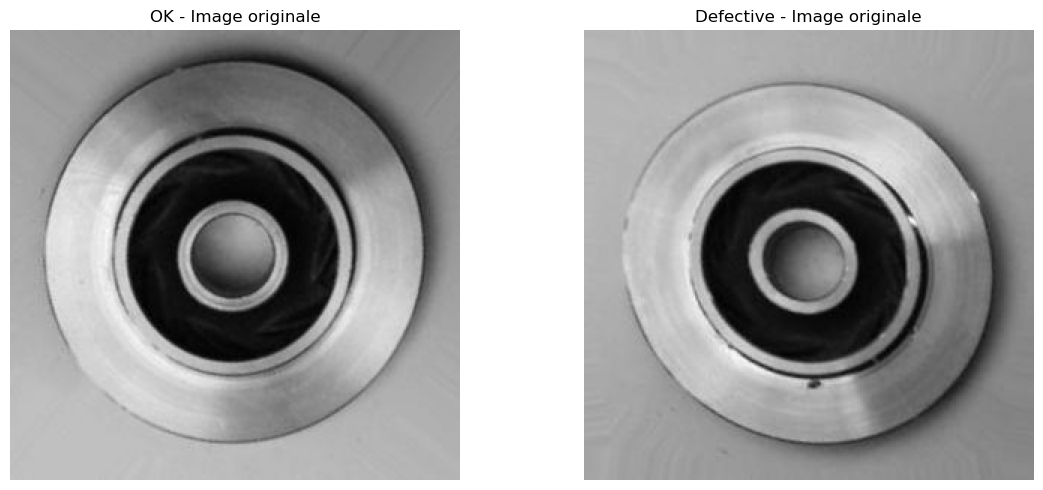

In [34]:
# ==========================================
# 5. Affichage des images originales
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(ok_img, cmap="gray")
axes[0].set_title("OK - Image originale")
axes[0].axis("off")

axes[1].imshow(def_img, cmap="gray")
axes[1].set_title("Defective - Image originale")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [35]:
# ==========================================
# 6. Prétraitement simple
# ==========================================

def preprocess_image(img, target_size=(256, 256)):
    """
    Prétraitement simple :
    1. redimensionnement
    2. normalisation des intensités entre 0 et 255
    """
    # redimensionner
    img_resized = cv2.resize(img, target_size)
    
    # normaliser
    img_normalized = cv2.normalize(img_resized, None, 0, 255, cv2.NORM_MINMAX)
    
    return img_normalized

In [36]:
# ==========================================
# 7. Application du prétraitement
# ==========================================

ok_pre = preprocess_image(ok_img, target_size=(256, 256))
def_pre = preprocess_image(def_img, target_size=(256, 256))

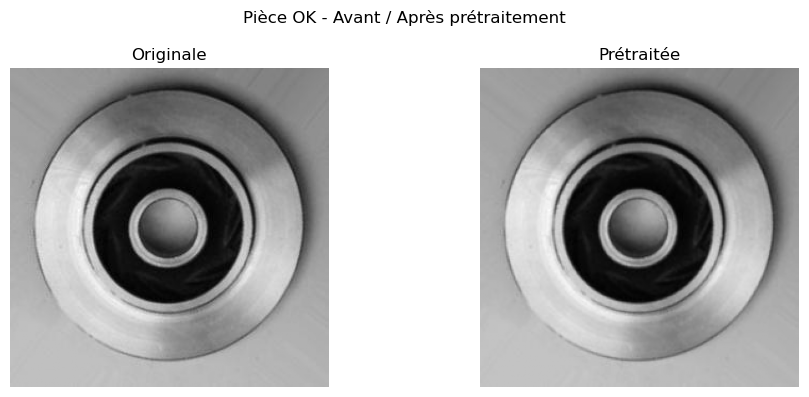

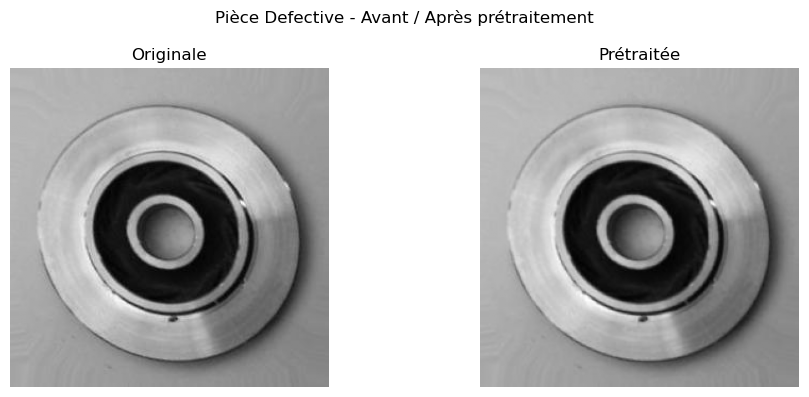

In [37]:
# ==========================================
# 8. Comparaison avant / après prétraitement
# ==========================================

def show_before_after(original, processed, title="Comparaison"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].imshow(original, cmap="gray")
    axes[0].set_title("Originale")
    axes[0].axis("off")
    
    axes[1].imshow(processed, cmap="gray")
    axes[1].set_title("Prétraitée")
    axes[1].axis("off")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_before_after(ok_img, ok_pre, title="Pièce OK - Avant / Après prétraitement")
show_before_after(def_img, def_pre, title="Pièce Defective - Avant / Après prétraitement")

In [38]:
# ==========================================
# 11. Application des filtres
# ==========================================

ok_gaussian = apply_gaussian_filter(ok_pre, kernel_size=(5, 5), sigma=0)
ok_median = apply_median_filter(ok_pre, kernel_size=5)

def_gaussian = apply_gaussian_filter(def_pre, kernel_size=(5, 5), sigma=0)
def_median = apply_median_filter(def_pre, kernel_size=5)

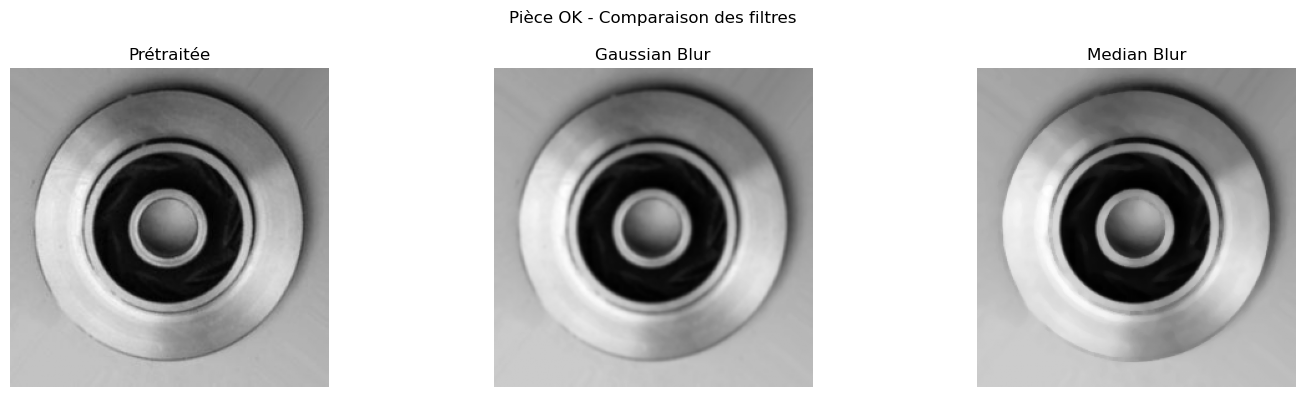

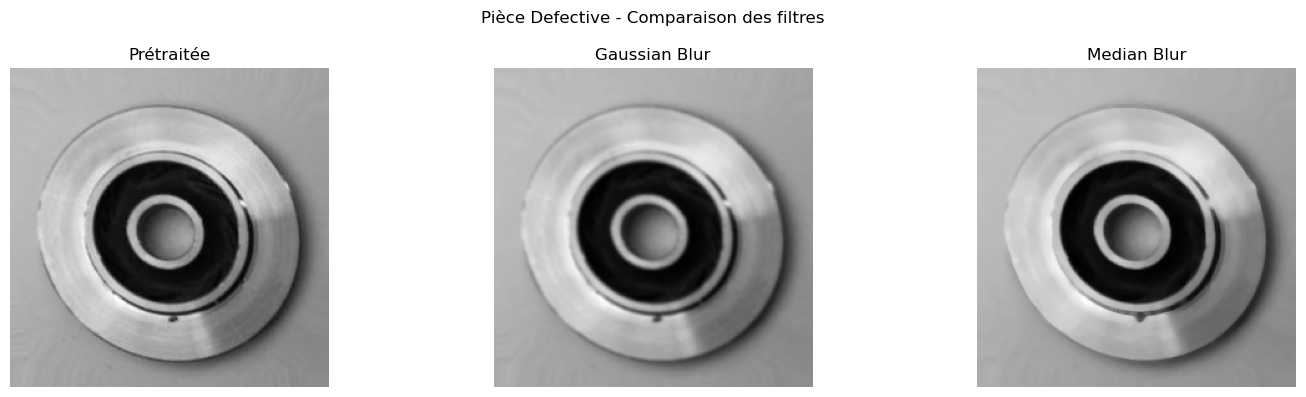

In [39]:
# ==========================================
# 12. Comparaison des filtres
# ==========================================

def compare_filters(img_original, img_gaussian, img_median, title="Comparaison des filtres"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].imshow(img_original, cmap="gray")
    axes[0].set_title("Prétraitée")
    axes[0].axis("off")
    
    axes[1].imshow(img_gaussian, cmap="gray")
    axes[1].set_title("Gaussian Blur")
    axes[1].axis("off")
    
    axes[2].imshow(img_median, cmap="gray")
    axes[2].set_title("Median Blur")
    axes[2].axis("off")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

compare_filters(ok_pre, ok_gaussian, ok_median, title="Pièce OK - Comparaison des filtres")
compare_filters(def_pre, def_gaussian, def_median, title="Pièce Defective - Comparaison des filtres")

In [40]:
# ==========================================
# 13. Statistiques simples
# ==========================================

def image_stats(img, name="Image"):
    print(name)
    print(" - shape :", img.shape)
    print(" - min   :", img.min())
    print(" - max   :", img.max())
    print(" - mean  :", round(float(img.mean()), 2))
    print(" - std   :", round(float(img.std()), 2))
    print()

image_stats(def_pre, "Defective - Prétraitée")
image_stats(def_gaussian, "Defective - Gaussian")
image_stats(def_median, "Defective - Median")

Defective - Prétraitée
 - shape : (256, 256)
 - min   : 0
 - max   : 255
 - mean  : 143.8
 - std   : 57.7

Defective - Gaussian
 - shape : (256, 256)
 - min   : 5
 - max   : 249
 - mean  : 143.8
 - std   : 56.53

Defective - Median
 - shape : (256, 256)
 - min   : 5
 - max   : 248
 - mean  : 144.29
 - std   : 57.1



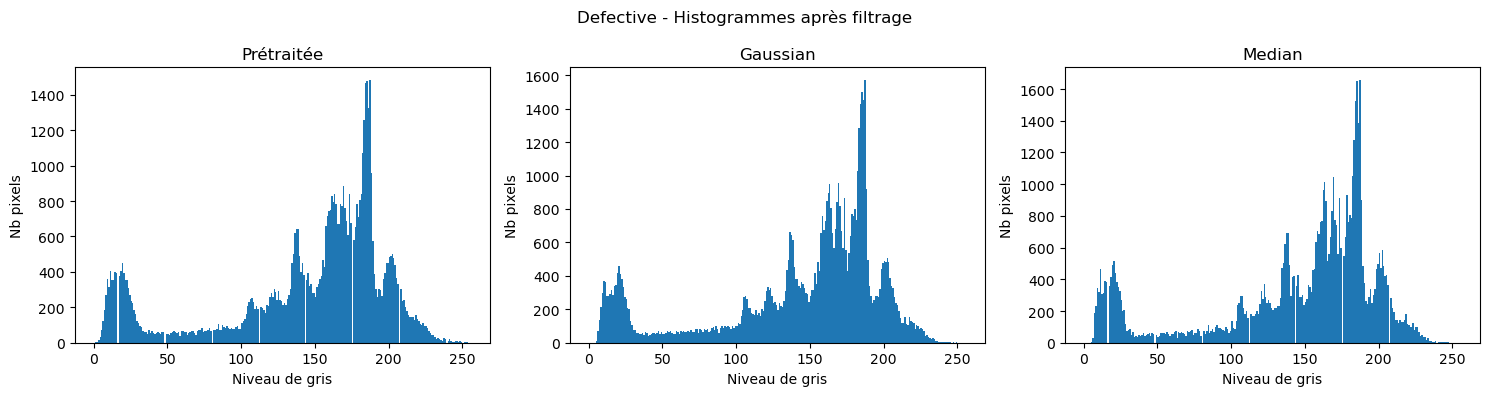

In [41]:
# ==========================================
# 14. Histogrammes avant / après filtrage
# ==========================================

def compare_histograms(images, titles, main_title="Histogrammes"):
    fig, axes = plt.subplots(1, len(images), figsize=(15, 4))
    
    if len(images) == 1:
        axes = [axes]
    
    for ax, img, title in zip(axes, images, titles):
        ax.hist(img.ravel(), bins=256, range=(0, 256))
        ax.set_title(title)
        ax.set_xlabel("Niveau de gris")
        ax.set_ylabel("Nb pixels")
    
    plt.suptitle(main_title)
    plt.tight_layout()
    plt.show()

compare_histograms(
    [def_pre, def_gaussian, def_median],
    ["Prétraitée", "Gaussian", "Median"],
    main_title="Defective - Histogrammes après filtrage"
)

In [42]:
# ==========================================
# 15. Test rapide sur plusieurs images
# ==========================================

def show_filter_examples(image_paths, class_name, n=3):
    selected_paths = random.sample(image_paths, min(n, len(image_paths)))
    
    for path in selected_paths:
        img = load_grayscale_image(path)
        img_pre = preprocess_image(img)
        img_g = apply_gaussian_filter(img_pre)
        img_m = apply_median_filter(img_pre)
        
        compare_filters(img_pre, img_g, img_m, title=f"{class_name} - {path.name}")

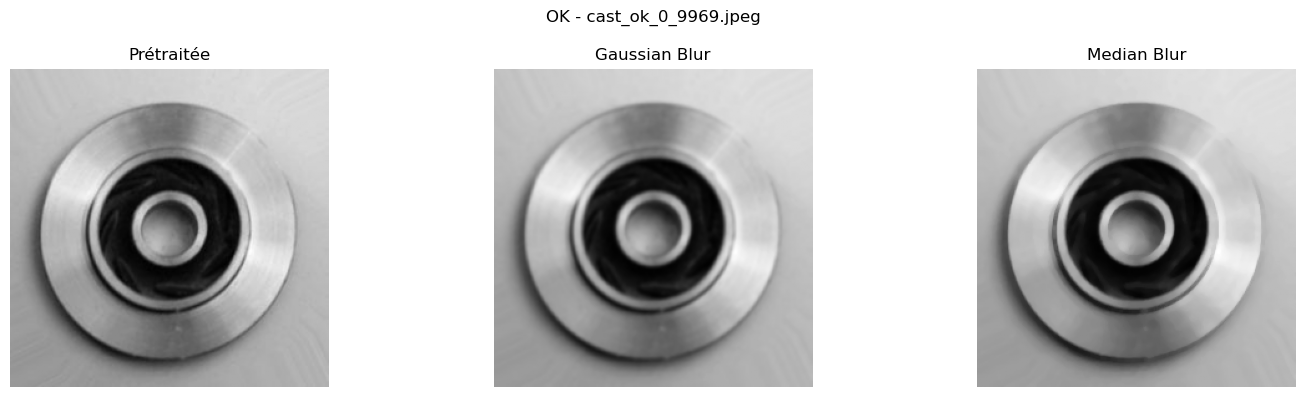

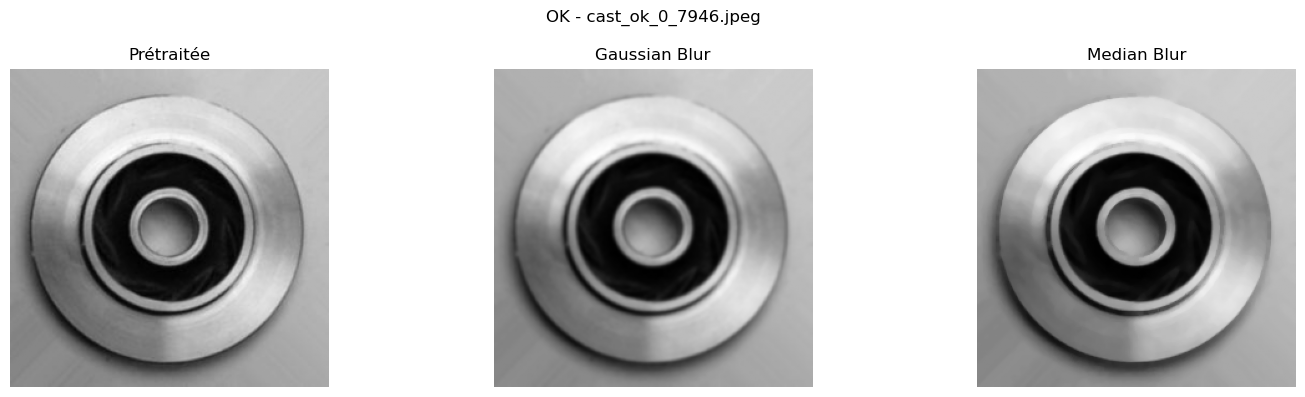

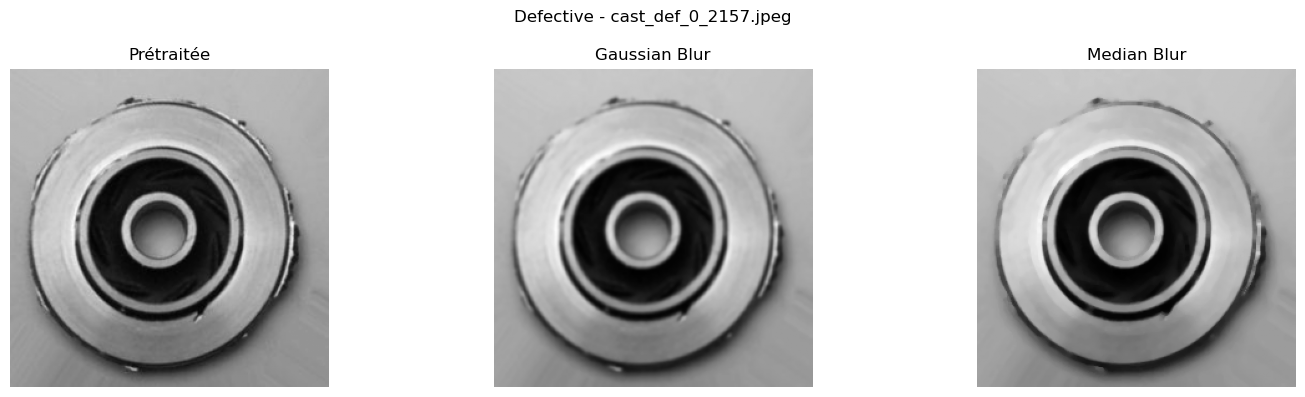

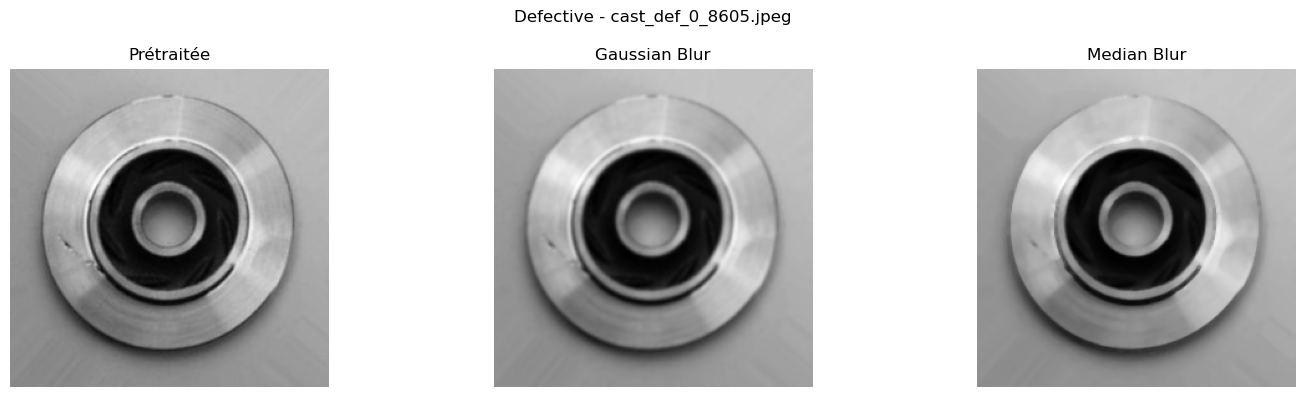

In [43]:
# ==========================================
# 16. Exemples multiples
# ==========================================

show_filter_examples(train_ok_images, "OK", n=2)
show_filter_examples(train_def_images, "Defective", n=2)